# Lab 1: Data Visualization, Data Preprocessing, and Statistical Analysis Using Python in Jupyter Notebook
**Name:** Anuj Shrestha

**Course:** MSCS 634

**Assignment:** Lab 1

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [3]:
# Load the Kaggle Titanic dataset into a Pandas DataFrame and save a local copy
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
df.to_csv("titanic.csv", index=False)

In [4]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


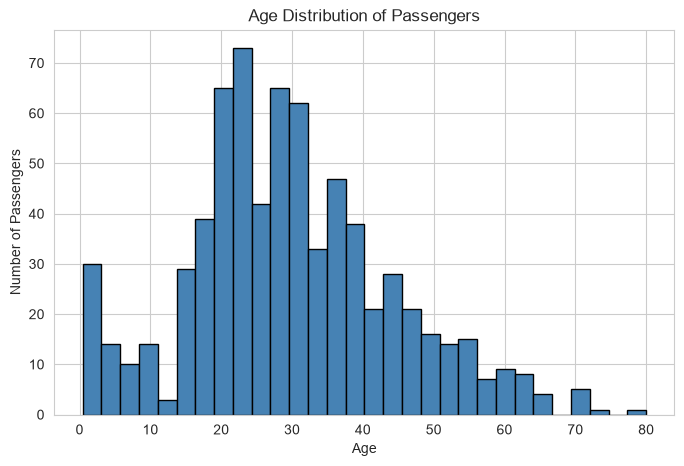

In [5]:
# Histogram: age distribution
plt.figure(figsize=(8,5))
plt.hist(df["Age"].dropna(), bins=30, color="steelblue", edgecolor="black")
plt.title("Age Distribution of Passengers")
plt.xlabel("Age"); plt.ylabel("Number of Passengers")
plt.show()

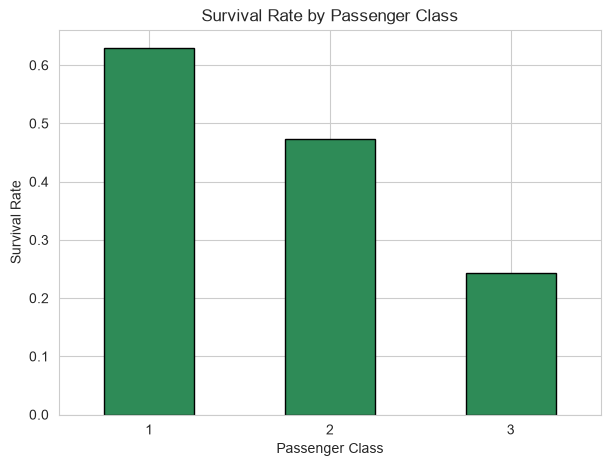

In [6]:
# Bar chart: survival rate by passenger class
plt.figure(figsize=(7,5))
df.groupby("Pclass")["Survived"].mean().plot(kind="bar", color="seagreen", edgecolor="black")
plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class"); plt.ylabel("Survival Rate")
plt.xticks(rotation=0)
plt.show()

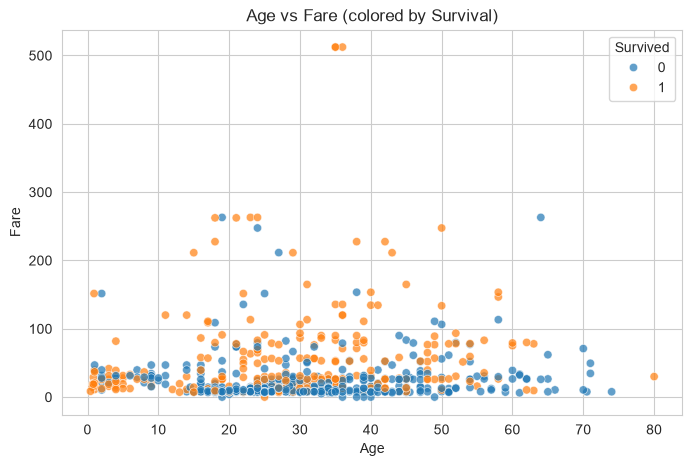

In [7]:
# Scatter plot: age vs fare
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Age", y="Fare", hue="Survived", alpha=0.7)
plt.title("Age vs Fare (colored by Survival)")
plt.show()

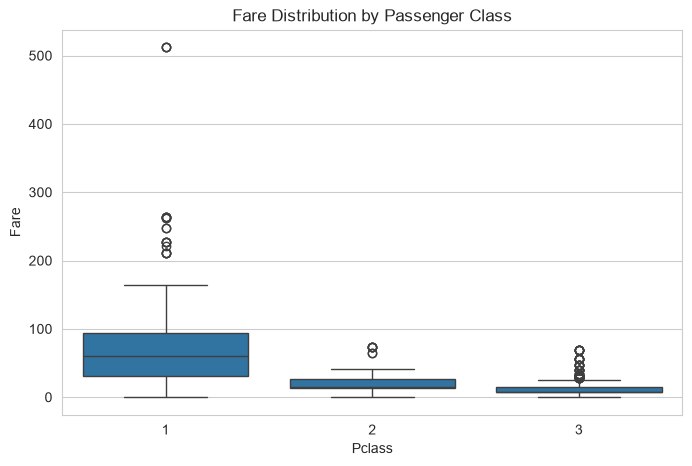

In [8]:
# Box plot: fare by class
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Pclass", y="Fare")
plt.title("Fare Distribution by Passenger Class")
plt.show()

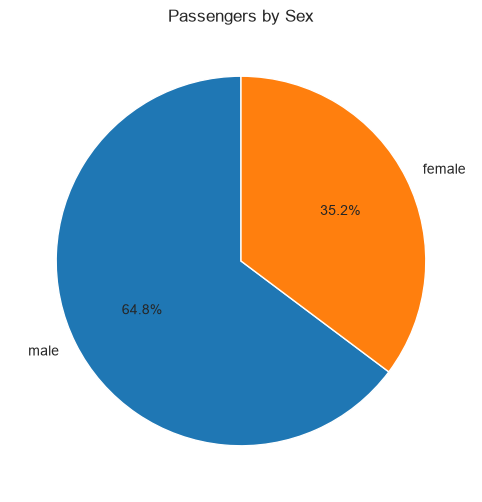

In [9]:
# Pie chart: passengers by sex
plt.figure(figsize=(6,6))
df["Sex"].value_counts().plot(kind="pie", autopct="%1.1f%%", startangle=90)
plt.title("Passengers by Sex"); plt.ylabel("")
plt.show()

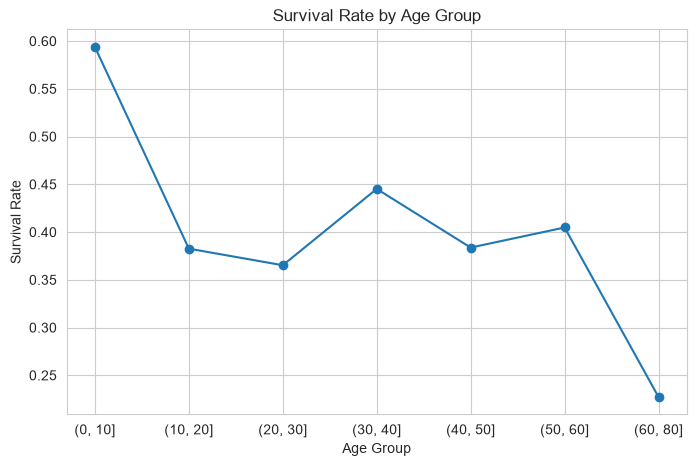

In [10]:
# Line plot: survival rate across age groups
age_bins = pd.cut(df["Age"], bins=[0,10,20,30,40,50,60,80])
rate = df.groupby(age_bins, observed=True)["Survived"].mean()
plt.figure(figsize=(8,5))
plt.plot(rate.index.astype(str), rate.values, marker="o")
plt.title("Survival Rate by Age Group")
plt.xlabel("Age Group"); plt.ylabel("Survival Rate")
plt.show()

In [11]:
print(df.isnull().sum())
df[df["Age"].isnull()].head()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
17,18,1,2,"Williams, Mr. Charles Eugene",male,NaN,0,0,244373,13.0000,NaN,S
19,20,1,3,"Masselmani, Mrs. Fatima",female,NaN,0,0,2649,7.2250,NaN,C
26,27,0,3,"Emir, Mr. Farred Chehab",male,NaN,0,0,2631,7.2250,NaN,C
28,29,1,3,"O'Dwyer, Miss. Ellen ""Nellie""",female,NaN,0,0,330959,7.8792,NaN,Q


In [12]:
df_clean = df.copy()

# Numeric column: fill with the median
df_clean["Age"] = df_clean["Age"].fillna(df_clean["Age"].median())
# Categorical column: fill with the mode
df_clean["Embarked"] = df_clean["Embarked"].fillna(df_clean["Embarked"].mode()[0])

# Drop columns with more than 50% missing values (Cabin)
missing_pct = df_clean.isnull().mean() * 100
cols_to_drop = missing_pct[missing_pct > 50].index
df_clean = df_clean.drop(columns=cols_to_drop)
print("Dropped columns:", list(cols_to_drop))

Dropped columns: ['Cabin']


In [13]:
print(df_clean.isnull().sum())
df_clean.loc[df[df["Age"].isnull()].head().index]

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
5,6,0,3,"Moran, Mr. James",male,28.0,0,0,330877,8.4583,Q
17,18,1,2,"Williams, Mr. Charles Eugene",male,28.0,0,0,244373,13.0000,S
19,20,1,3,"Masselmani, Mrs. Fatima",female,28.0,0,0,2649,7.2250,C
26,27,0,3,"Emir, Mr. Farred Chehab",male,28.0,0,0,2631,7.2250,C
28,29,1,3,"O'Dwyer, Miss. Ellen ""Nellie""",female,28.0,0,0,330959,7.8792,Q


In [14]:
Q1 = df_clean["Fare"].quantile(0.25)
Q3 = df_clean["Fare"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
print(f"Q1={Q1}, Q3={Q3}, IQR={IQR:.2f}")
print(f"Lower bound={lower:.2f}, Upper bound={upper:.2f}")

outliers = df_clean[(df_clean["Fare"] < lower) | (df_clean["Fare"] > upper)]
print("Number of outliers:", len(outliers))
outliers[["Name","Pclass","Fare"]].sort_values("Fare", ascending=False).head(10)

Q1=7.9104, Q3=31.0, IQR=23.09
Lower bound=-26.72, Upper bound=65.63
Number of outliers: 116


,Name,Pclass,Fare
258,"Ward, Miss. Anna",1,512.3292
737,"Lesurer, Mr. Gustave J",1,512.3292
679,"Cardeza, Mr. Thomas Drake Martinez",1,512.3292
27,"Fortune, Mr. Charles Alexander",1,263.0000
341,"Fortune, Miss. Alice Elizabeth",1,263.0000
438,"Fortune, Mr. Mark",1,263.0000
88,"Fortune, Miss. Mabel Helen",1,263.0000
311,"Ryerson, Miss. Emily Borie",1,262.3750
742,"Ryerson, Miss. Susan Parker ""Suzette""",1,262.3750
299,"Baxter, Mrs. James (Helene DeLaudeniere Chaput)",1,247.5208


In [15]:
print("Before:", df_clean.shape)
df_no_out = df_clean[(df_clean["Fare"] >= lower) & (df_clean["Fare"] <= upper)].copy()
print("After:", df_no_out.shape)
df_no_out["Fare"].describe()

Before: (891, 11)
After: (775, 11)


count    775.000000
mean      17.822091
std       13.578085
min        0.000000
25%        7.895800
50%       13.000000
75%       26.000000
max       65.000000
Name: Fare, dtype: float64

In [16]:
print("Before:", df_no_out.shape)
df_no_out.head()

Before: (775, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
5,6,0,3,"Moran, Mr. James",male,28.0,0,0,330877,8.4583,Q


In [17]:
# Sampling: keep 50% of the rows
df_sample = df_no_out.sample(frac=0.5, random_state=42)
# Dimension elimination: drop identifier columns that add no analytical value
df_reduced = df_sample.drop(columns=["PassengerId", "Name", "Ticket"])
print("After:", df_reduced.shape)
df_reduced.head()

After: (388, 8)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
493,0,1,male,71.0,0,0,49.5042,C
821,1,3,male,27.0,0,0,8.6625,S
381,1,3,female,1.0,0,2,15.7417,C
881,0,3,male,33.0,0,0,7.8958,S
420,0,3,male,28.0,0,0,7.8958,C


In [18]:
df_scaled = df_reduced.copy()
df_scaled[["Age","Fare"]].head()

,Age,Fare
493,71.0,49.5042
821,27.0,8.6625
381,1.0,15.7417
881,33.0,7.8958
420,28.0,7.8958


In [19]:
# Min-Max scaling
for col in ["Age", "Fare"]:
    df_scaled[col + "_MinMax"] = (df_scaled[col] - df_scaled[col].min()) / (df_scaled[col].max() - df_scaled[col].min())

# Z-score standardization
df_scaled["Fare_Z"] = (df_scaled["Fare"] - df_scaled["Fare"].mean()) / df_scaled["Fare"].std()

# Discretization: continuous values into categories
df_scaled["Age_Group"] = pd.cut(df_scaled["Age"], bins=[0,12,18,35,60,100],
                                labels=["Child","Teen","Young Adult","Adult","Senior"])
df_scaled["Fare_Level"] = pd.qcut(df_scaled["Fare"], q=3, labels=["Low","Medium","High"])

df_scaled[["Age","Age_MinMax","Age_Group","Fare","Fare_MinMax","Fare_Z","Fare_Level"]].head(10)

,Age,Age_MinMax,Age_Group,Fare,Fare_MinMax,Fare_Z,Fare_Level
493,71.0,0.959089,Senior,49.5042,0.761603,2.149582,High
821,27.0,0.359062,Young Adult,8.6625,0.133269,-0.670191,Medium
381,1.0,0.004500,Child,15.7417,0.242180,-0.181433,Medium
881,33.0,0.440884,Young Adult,7.8958,0.121474,-0.723126,Low
420,28.0,0.372699,Young Adult,7.8958,0.121474,-0.723126,Low
623,21.0,0.277240,Young Adult,7.8542,0.120834,-0.725998,Low
850,4.0,0.045411,Child,31.2750,0.481154,0.891010,High
241,28.0,0.372699,Young Adult,15.5000,0.238462,-0.198120,Medium
133,29.0,0.386336,Young Adult,26.0000,0.400000,0.526816,High
599,49.0,0.659075,Adult,56.9292,0.875834,2.662216,High


In [20]:
df_no_out.info()

<class 'pandas.DataFrame'>
Index: 775 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  775 non-null    int64  
 1   Survived     775 non-null    int64  
 2   Pclass       775 non-null    int64  
 3   Name         775 non-null    str    
 4   Sex          775 non-null    str    
 5   Age          775 non-null    float64
 6   SibSp        775 non-null    int64  
 7   Parch        775 non-null    int64  
 8   Ticket       775 non-null    str    
 9   Fare         775 non-null    float64
 10  Embarked     775 non-null    str    
dtypes: float64(2), int64(5), str(4)
memory usage: 72.7 KB


In [21]:
df_no_out.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,775.000000,775.000000,775.00000,775.000000,775.000000,775.000000,775.000000
mean,445.806452,0.339355,2.48000,28.748710,0.437419,0.340645,17.822091
std,260.116285,0.473796,0.73439,12.782123,0.899838,0.785914,13.578085
min,1.000000,0.000000,1.00000,0.420000,0.000000,0.000000,0.000000
25%,213.500000,0.000000,2.00000,22.000000,0.000000,0.000000,7.895800
50%,450.000000,0.000000,3.00000,28.000000,0.000000,0.000000,13.000000
75%,670.500000,1.000000,3.00000,34.000000,1.000000,0.000000,26.000000
max,891.000000,1.000000,3.00000,80.000000,5.000000,6.000000,65.000000


In [22]:
num_cols = ["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare"]
central = pd.DataFrame({
    "Min": df_no_out[num_cols].min(),
    "Max": df_no_out[num_cols].max(),
    "Mean": df_no_out[num_cols].mean(),
    "Median": df_no_out[num_cols].median(),
    "Mode": df_no_out[num_cols].mode().iloc[0]
})
central.round(2)

,Min,Max,Mean,Median,Mode
Survived,0.00,1.0,0.34,0.0,0.00
Pclass,1.00,3.0,2.48,3.0,3.00
Age,0.42,80.0,28.75,28.0,28.00
SibSp,0.00,5.0,0.44,0.0,0.00
Parch,0.00,6.0,0.34,0.0,0.00
Fare,0.00,65.0,17.82,13.0,8.05


In [23]:
dispersion = pd.DataFrame({
    "Range": df_no_out[num_cols].max() - df_no_out[num_cols].min(),
    "Q1": df_no_out[num_cols].quantile(0.25),
    "Q2 (Median)": df_no_out[num_cols].quantile(0.50),
    "Q3": df_no_out[num_cols].quantile(0.75),
    "IQR": df_no_out[num_cols].quantile(0.75) - df_no_out[num_cols].quantile(0.25),
    "Variance": df_no_out[num_cols].var(),
    "Std Dev": df_no_out[num_cols].std()
})
dispersion.round(2)

,Range,Q1,Q2 (Median),Q3,IQR,Variance,Std Dev
Survived,1.00,0.0,0.0,1.0,1.0,0.22,0.47
Pclass,2.00,2.0,3.0,3.0,1.0,0.54,0.73
Age,79.58,22.0,28.0,34.0,12.0,163.38,12.78
SibSp,5.00,0.0,0.0,1.0,1.0,0.81,0.90
Parch,6.00,0.0,0.0,0.0,0.0,0.62,0.79
Fare,65.00,7.9,13.0,26.0,18.1,184.36,13.58


In [24]:
corr = df_no_out[num_cols].corr()
corr.round(2)

,Survived,Pclass,Age,SibSp,Parch,Fare
Survived,1.00,-0.24,-0.12,-0.00,0.10,0.23
Pclass,-0.24,1.00,-0.35,0.11,0.08,-0.59
Age,-0.12,-0.35,1.00,-0.33,-0.20,0.09
SibSp,-0.00,0.11,-0.33,1.00,0.41,0.37
Parch,0.10,0.08,-0.20,0.41,1.00,0.34
Fare,0.23,-0.59,0.09,0.37,0.34,1.00


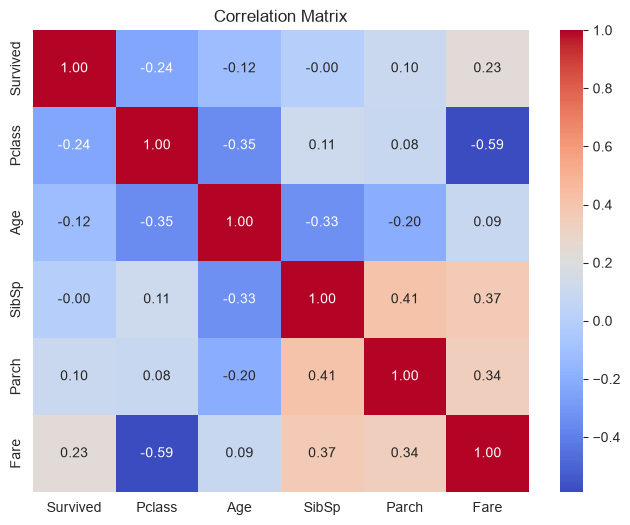

In [25]:
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()